##Задача

* Найти данные в виде изображений для задачи классификации. Например, можно взять данные [отсюда](http://ufldl.stanford.edu/housenumbers/).
* Реализовать классы, необходимые для построения сети со следующими слоями
  * FullyConnectedLayer
  * ReluLayer
  * FullyConnectedLayer
* Использовать CrossEntropyLoss и L2-регуляризацию.
* Обучить модель на тренировочных данных, подбирать параметры (особенно learning rate) на валидационной и оценить качество на тестовой. Анализировать графики train/val loss, проверять на каждом шаге корректность вычисления градиентов с помощью разностной оценки.
 * (+2 балла) Добавить Batch normalization.
 * (+2 балла) В качестве оптимизатор использовать один из: Momentum, RMSprop.
 * (+1 балл) Также реализовать оптимизатор Adam.

## Датасет
Для задачи классификации возьмем предложенный датасет [The Street View House Numbers (SVHN) Dataset](http://ufldl.stanford.edu/housenumbers/). Каждая картинка 32х32 содержит номер дома, сфотографированный на улице.


In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

print(torch.__version__)

2.10.0+cpu


**Загрузка датасета SVHN**

In [42]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

**DataLoader**

In [43]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [44]:
images, labels = next(iter(train_loader))
labels = labels % 10
print(images.shape)  # должно быть [64, 3, 32, 32]
print(labels[:10])
print(labels.unique())

torch.Size([64, 3, 32, 32])
tensor([7, 7, 5, 4, 4, 0, 2, 0, 2, 5])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


**Визуализация изображений**

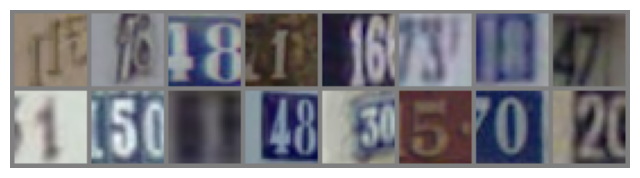

Labels: tensor([1, 1, 8, 1, 1, 3, 8, 7, 1, 5, 1, 4, 3, 5, 0, 2])


In [45]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(images, labels):
    images = images / 2 + 0.5
    npimg = images.numpy()

    plt.figure(figsize=(8, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

images, labels = next(iter(train_loader))
labels = labels % 10

show_batch(torchvision.utils.make_grid(images[:16]), labels[:16])
print("Labels:", labels[:16])

**Train / Validation split**

In [46]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_data,
    batch_size=64,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)
print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_dataset))

Train: 58605
Val: 14652
Test: 26032


## Построение сети

`W` — веса \
`b` — смещение \
`nn.Parameter` → PyTorch будет считать градиенты \
`@` → матричное умножение

In [47]:
class FullyConnectedLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.W = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.b = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        return x @ self.W.t() + self.b

In [48]:
class ReluLayer(nn.Module):
    def forward(self, x):
        return torch.relu(x)

## Нейронная сеть с batch normalization

In [49]:
class SimpleNet(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()

        self.use_bn = use_bn
        self.flatten = nn.Flatten()

        self.fc1 = FullyConnectedLayer(3*32*32, 256)
        self.bn1 = nn.BatchNorm1d(256) if use_bn else None
        self.relu = ReluLayer()
        self.fc2 = FullyConnectedLayer(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

## Оптимизатор Adam

In [50]:
class AdamOptimizer:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps

        self.m = {}
        self.v = {}
        self.t = 0

        for i, p in enumerate(self.params):
            self.m[i] = torch.zeros_like(p.data)
            self.v[i] = torch.zeros_like(p.data)

    def step(self):
        self.t += 1

        for i, p in enumerate(self.params):
            if p.grad is None:
                continue

            g = p.grad.data

            # moment 1
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g

            # moment 2
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g ** 2)

            # bias correction
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            # update
            p.data -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

**Проверка градиентов с помощью разностной оценки**\
`model`: модель\
`criterion`: функция потерь \
`inputs`: входные данные (один батч)\
`labels`: целевые метки\
`epsilon`: шаг для численного дифференцирования\
`tolerance`: допустимая относительная ошибка\
`max_checks`: максимальное количество проверяемых параметров на слой

In [51]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def gradient_check(model, inputs, targets, criterion, delta=1e-3):
    model.eval()
    model.zero_grad()
    output = model(inputs)
    loss = criterion(output, targets)
    loss.backward()

    param_list = [param for param in model.parameters() if param.requires_grad]
    total_params = sum(p.numel() for p in param_list)
    num_checks = 15

    if num_checks > total_params:
        num_checks = total_params

    selected_indices = torch.randperm(total_params)[:num_checks]

    for param in param_list:
        param_data_flat = param.data.view(-1)
        param_grad_flat = param.grad.view(-1)

        for idx in selected_indices:
            if idx >= param_data_flat.size(0):
                break

            original_value = param_data_flat[idx].item()

            param_data_flat[idx] = original_value + delta
            loss_plus = criterion(model(inputs), targets).item()

            param_data_flat[idx] = original_value - delta
            loss_minus = criterion(model(inputs), targets).item()

            param_data_flat[idx] = original_value

            estimated_grad = (loss_plus - loss_minus) / (2 * delta)
            actual_grad = param_grad_flat[idx].item()

            if abs(estimated_grad - actual_grad) > delta:
                print(f"abs {estimated_grad - actual_grad} delta {delta}")
                print("✗ Some gradient checks FAILED!")
                return False

    print("✓ All gradient checks PASSED!")
    return True

## Train loop

In [52]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0

    for images, labels in loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

## Val loop

In [53]:
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    acc = correct / len(loader.dataset)
    return total_loss / len(loader), acc

## Подбор learning rate и других параметров (модель, оптимизатор)

In [60]:
criterion = nn.CrossEntropyLoss()

def run_training(model, optimizer):
  train_losses = []
  val_losses = []
  for epoch in range(10):
      train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
      val_loss, val_acc = evaluate(model, val_loader, criterion)

      sample_x, sample_y = next(iter(train_loader))
      sample_x, sample_y = sample_x[:8].to(device), sample_y[:8].to(device)
      print(f"Gradient check at epoch {epoch+1}:")
      gradient_check(model, sample_x, sample_y, criterion)

      train_losses.append(train_loss)
      val_losses.append(val_loss)

      print(f"Epoch {epoch+1}")
      print(f"train: {train_loss:.4f} | val: {val_loss:.4f} | acc: {val_acc:.4f}")
  return train_losses, val_losses


In [61]:
def plot_results(train_losses, val_losses):
  plt.plot(train_losses, label="train")
  plt.plot(val_losses, label="val")
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.title("Loss curves")
  plt.show()

In [62]:
def clear_results():
  train_losses = []
  val_losses = []
  val_accs = []

model: Batch normalization, optimizer: Adam, lr = 0.01
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 1.3314 | val: 1.0691 | acc: 0.6731
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.9625 | val: 0.8933 | acc: 0.7273
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.8544 | val: 0.8091 | acc: 0.7583
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.7994 | val: 0.7848 | acc: 0.7719
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.7594 | val: 0.7119 | acc: 0.7933
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.7340 | val: 0.7181 | acc: 0.7933
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.7094 | val: 0.7097 | acc: 0.7911
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.6879 | val: 0.6902 | acc: 0.8008
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.6778 | val: 0.6

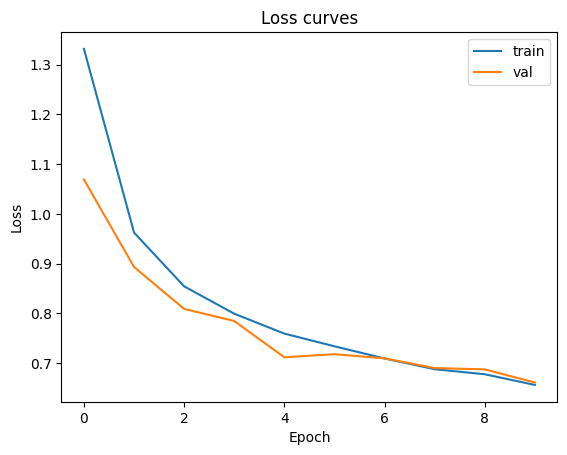

model: Batch normalization, optimizer: Momentum, lr = 0.01
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.5796 | val: 0.6051 | acc: 0.8277
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.5625 | val: 0.6049 | acc: 0.8260
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.5546 | val: 0.5945 | acc: 0.8321
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.5476 | val: 0.5836 | acc: 0.8346
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.5426 | val: 0.5876 | acc: 0.8344
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.5435 | val: 0.5827 | acc: 0.8376
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.5374 | val: 0.5829 | acc: 0.8361
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.5370 | val: 0.5766 | acc: 0.8385
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.5365 | val:

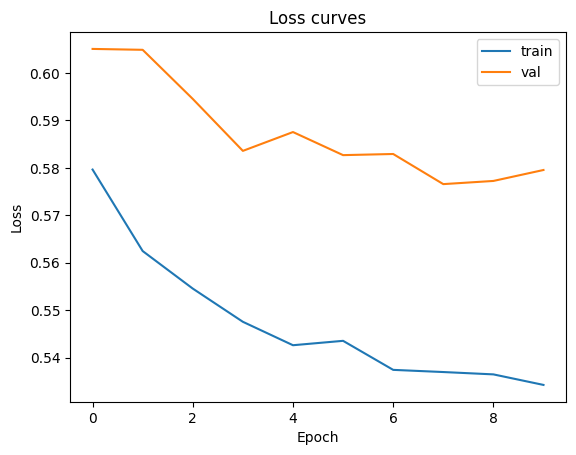

model: Simple, optimizer: Adam, lr = 0.01
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 2.5000 | val: 2.3165 | acc: 0.5656
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 2.2267 | val: 2.7728 | acc: 0.5763
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 2.2354 | val: 2.2550 | acc: 0.6514
Gradient check at epoch 4:
abs 0.0012043165042996407 delta 0.001
✗ Some gradient checks FAILED!
Epoch 4
train: 2.2449 | val: 7.1120 | acc: 0.5859
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 2.0805 | val: 3.5326 | acc: 0.5851
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 2.2703 | val: 1.7196 | acc: 0.6916
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 1.8989 | val: 2.2373 | acc: 0.6516
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 2.3753 | val: 1.7895 | acc: 0.6688
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 

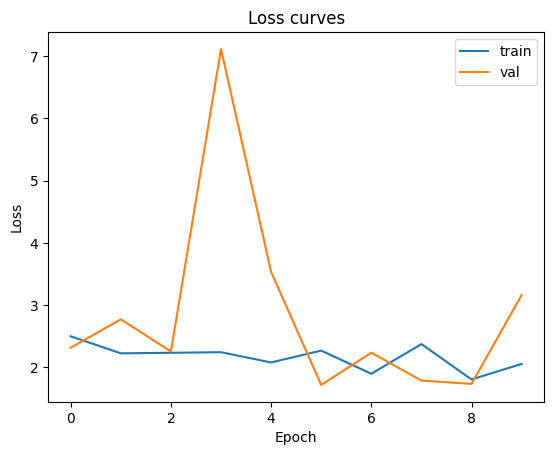

model: Simple, optimizer: Momentum, lr = 0.01
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 2.3948 | val: 2.5581 | acc: 0.7318
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 1.8222 | val: 2.3090 | acc: 0.7347
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 1.6131 | val: 2.1656 | acc: 0.7407
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 1.4468 | val: 1.9952 | acc: 0.7388
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 1.3491 | val: 1.8609 | acc: 0.7394
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 1.3218 | val: 1.8371 | acc: 0.7349
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 1.2344 | val: 1.6956 | acc: 0.7473
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 1.1664 | val: 1.7324 | acc: 0.7432
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 1.1325 | val: 1.8072 | acc

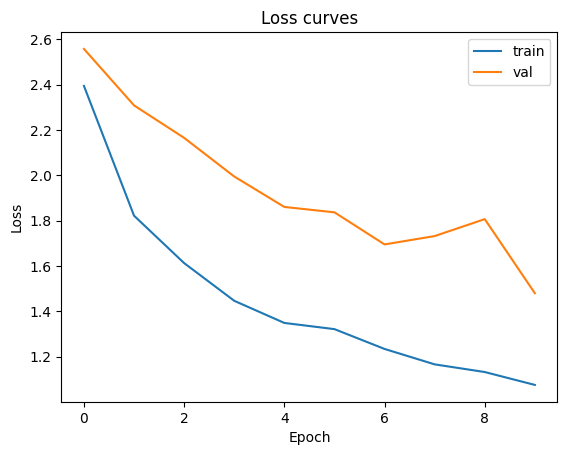

model: Batch normalization, optimizer: Adam, lr = 0.001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.5325 | val: 0.5725 | acc: 0.8408
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.5220 | val: 0.5682 | acc: 0.8417
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.5158 | val: 0.5720 | acc: 0.8417
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.5156 | val: 0.5688 | acc: 0.8433
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.5127 | val: 0.5655 | acc: 0.8443
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.5060 | val: 0.5623 | acc: 0.8437
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.5030 | val: 0.5611 | acc: 0.8462
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.5042 | val: 0.5607 | acc: 0.8468
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.5052 | val: 0.

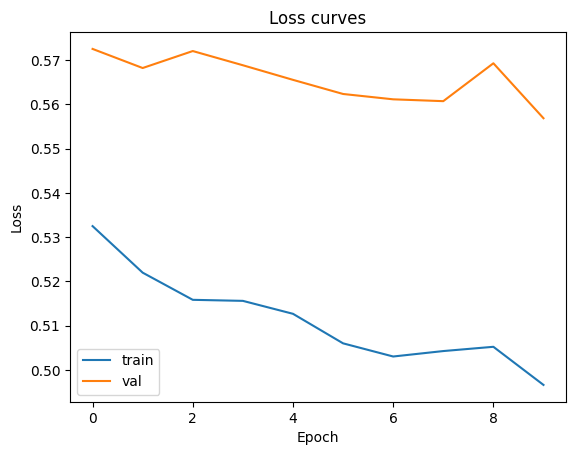

model: Batch normalization, optimizer: Momentum, lr = 0.001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.4849 | val: 0.5565 | acc: 0.8472
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.4816 | val: 0.5520 | acc: 0.8479
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.4822 | val: 0.5535 | acc: 0.8469
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.4857 | val: 0.5507 | acc: 0.8480
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.4835 | val: 0.5544 | acc: 0.8479
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.4811 | val: 0.5531 | acc: 0.8485
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.4805 | val: 0.5563 | acc: 0.8487
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.4813 | val: 0.5510 | acc: 0.8481
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.4793 | val

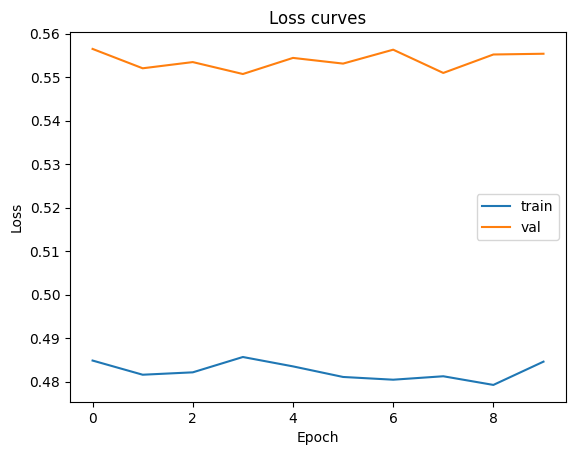

model: Simple, optimizer: Adam, lr = 0.001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.8714 | val: 1.1938 | acc: 0.7763
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.7291 | val: 1.0890 | acc: 0.7809
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.6562 | val: 0.9960 | acc: 0.7855
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.6116 | val: 0.9260 | acc: 0.7933
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.5953 | val: 0.9655 | acc: 0.7837
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.5733 | val: 0.8943 | acc: 0.7930
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.5483 | val: 0.9374 | acc: 0.7871
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.5428 | val: 0.8759 | acc: 0.7940
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.5357 | val: 0.8444 | acc: 0

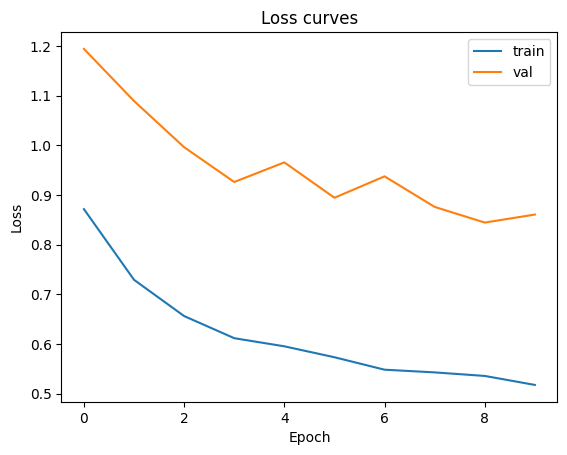

model: Simple, optimizer: Momentum, lr = 0.001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.4714 | val: 0.8215 | acc: 0.8053
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.4567 | val: 0.8163 | acc: 0.8056
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.4522 | val: 0.8075 | acc: 0.8069
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.4484 | val: 0.8084 | acc: 0.8084
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.4475 | val: 0.8145 | acc: 0.8044
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.4449 | val: 0.8098 | acc: 0.8084
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.4431 | val: 0.8106 | acc: 0.8081
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.4428 | val: 0.8118 | acc: 0.8075
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.4404 | val: 0.8238 | ac

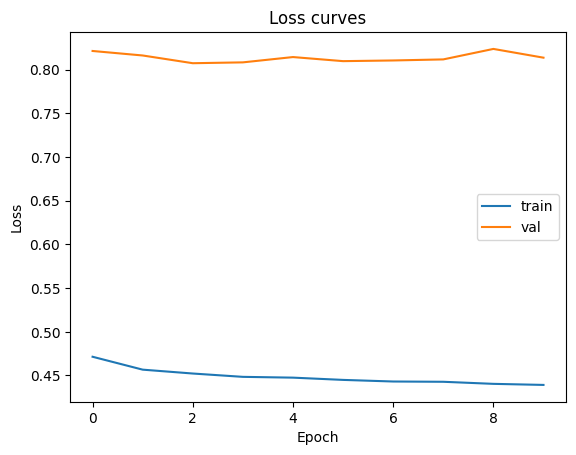

model: Batch normalization, optimizer: Adam, lr = 0.0001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.4805 | val: 0.5559 | acc: 0.8463
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.4797 | val: 0.5499 | acc: 0.8488
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.4788 | val: 0.5519 | acc: 0.8479
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.4811 | val: 0.5517 | acc: 0.8492
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.4789 | val: 0.5530 | acc: 0.8490
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.4807 | val: 0.5526 | acc: 0.8508
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.4770 | val: 0.5520 | acc: 0.8492
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.4770 | val: 0.5504 | acc: 0.8488
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.4772 | val: 0

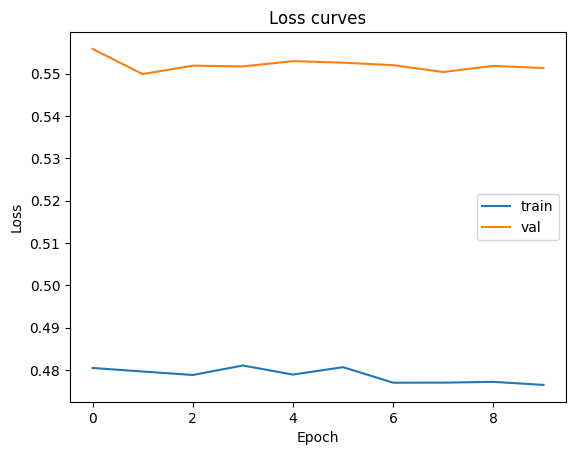

model: Batch normalization, optimizer: Momentum, lr = 0.0001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.4768 | val: 0.5524 | acc: 0.8487
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.4752 | val: 0.5539 | acc: 0.8486
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.4770 | val: 0.5547 | acc: 0.8483
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.4781 | val: 0.5568 | acc: 0.8478
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.4735 | val: 0.5514 | acc: 0.8495
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.4737 | val: 0.5512 | acc: 0.8497
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.4766 | val: 0.5511 | acc: 0.8483
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.4753 | val: 0.5523 | acc: 0.8493
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.4742 | va

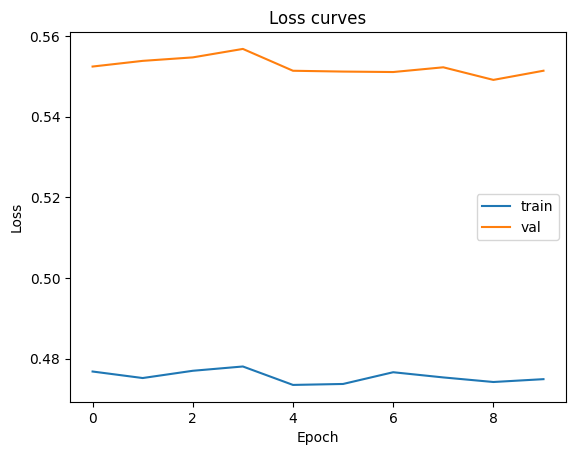

model: Simple, optimizer: Adam, lr = 0.0001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.4294 | val: 0.8088 | acc: 0.8103
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.4203 | val: 0.8104 | acc: 0.8095
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.4150 | val: 0.8122 | acc: 0.8092
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.4105 | val: 0.8162 | acc: 0.8101
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.4070 | val: 0.8189 | acc: 0.8091
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.4032 | val: 0.8229 | acc: 0.8092
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.4003 | val: 0.8236 | acc: 0.8091
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.3971 | val: 0.8259 | acc: 0.8093
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.3943 | val: 0.8293 | acc: 

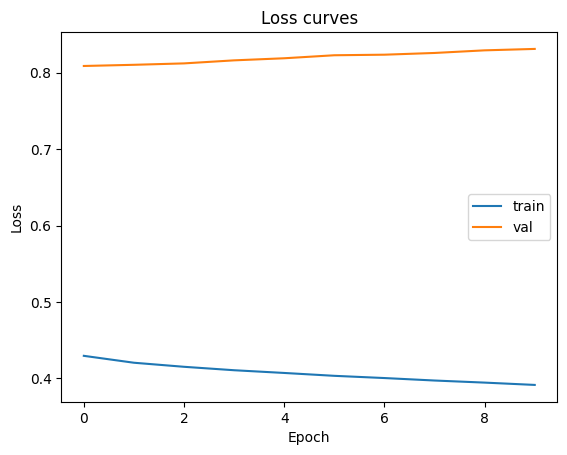

model: Simple, optimizer: Momentum, lr = 0.0001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.3844 | val: 0.8312 | acc: 0.8097
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.3839 | val: 0.8307 | acc: 0.8094
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.3833 | val: 0.8301 | acc: 0.8105
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.3831 | val: 0.8312 | acc: 0.8100
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.3828 | val: 0.8319 | acc: 0.8098
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.3827 | val: 0.8313 | acc: 0.8095
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.3824 | val: 0.8319 | acc: 0.8103
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.3823 | val: 0.8318 | acc: 0.8094
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.3821 | val: 0.8330 | a

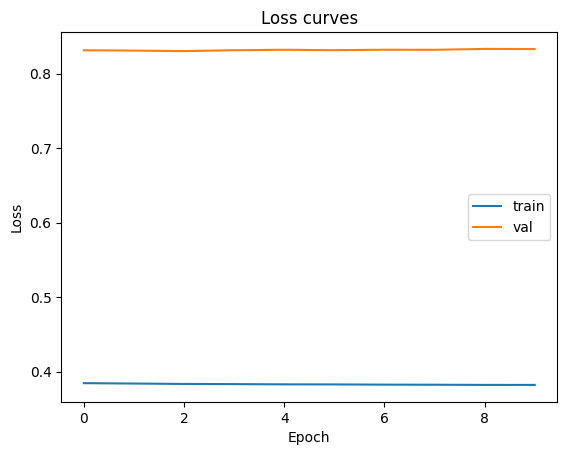

In [63]:
lrs = [1e-2, 1e-3, 1e-4]
models = [SimpleNet(use_bn=True), SimpleNet()]
models_print = ["Batch normalization", "Simple"]
for lr in lrs:
      opt_print = ["Adam", "Momentum"]
      for i in range(len(models)):
            model = models[i]
            optimizer_Adam = AdamOptimizer(model.parameters(), lr=lr)
            optimizer_SGD = torch.optim.SGD(
                model.parameters(),
                lr=lr,
                momentum=0.9,
                weight_decay=1e-4
            )
            optimizers = [optimizer_Adam, optimizer_SGD]
            for j in range(len(optimizers)):
                  print(f"model: {models_print[i]}, optimizer: {opt_print[j]}, lr = {lr}")
                  train_losses, val_losses = run_training(model, optimizers[j])
                  plot_results(train_losses, val_losses)


=> лучший learning rate = 0.001, результаты лучше с batch normalization и оптимизатором Momentum

In [64]:
model = SimpleNet(use_bn=True)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9,
    weight_decay=1e-4
)
for epoch in range(10):
      train_one_epoch(model, test_loader, optimizer, criterion)
test_loss, test_acc = evaluate(model, test_loader, criterion)

print("TEST LOSS:", test_loss)
print("TEST ACC:", test_acc)

TEST LOSS: 0.7020536256217254
TEST ACC: 0.810540872771973
